In [ ]:
#/*
#By: Patrick Burns [pb463@nau.edu], Northern Arizona University
#    Some code provided by USFS (Zhiqiang Yang and GTAC) and Paulo Arevalo

#About: explore various dimensions of CCDC result images

#*/


In [1]:
# Imports
import ee
import geemap
import os
import math
from geemap import chart

In [2]:
# Initialize Earth Engine
ee.Initialize()

In [3]:
# VIZ
pal_viridis = ['#440154', '#433982', '#30678D', '#218F8B', '#36B677', '#8ED542', '#FDE725']

#// false color visualiztion params for synthetic Landsat images
lsat_fcolor_viz = {'bands': ['SWIR1', 'NIR', 'red'], 'min':0, 'max':0.45}

In [6]:
#// ----------------------
#// ----- INPUTS -----
#// ----------------------
#// region of interest
region_geom = ee.Feature(ee.FeatureCollection('users/pb463/S2L/Sonoma_cty_v2_PBcleaned').first()) \
                    .geometry()
# path to CCDC assets (a directory of CCDC array images)
ccdc_assets_path = 'projects/ee-gedibio/assets/ccdc/results/workshop_sonoma'
bands = ['green', 'red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'NDMI', 'NBR2']
indices = ['NDVI', 'NDMI', 'NBR2']

#// CCDC start and end years
start_year = 1985
end_year = 2024

#// GEDI and ALS assets
gedi_fc = ee.FeatureCollection('projects/ee-gedibio/assets/gedi/vector_uploads/L2AB_002_2019-04-01_2021-09-30_DOY91_273_US-CA-Sonoma3_shifted') \
                .filterBounds(region_geom) \
                .filter(ee.Filter.gte('doy',150)) \
                .filter(ee.Filter.lt('doy',270))

gedi_y_lim = 1000

gedi_predext_asset = 'projects/ee-gedibio/assets/gedi_ccdc_predext_sonoma_tswork_15k'

als_chm = ee.Image('users/pb463/als_ca-sonoma2013_chm_mos_3m') \
                .rename('ALS_CHM')
gedi_fc.limit(10)


In [5]:
#// ----------------------
#// ----- PROCESSING -----
#// ----------------------

# load the ccdc result assets as a mosaiced image
ccdc_assets = [i['id'] for i in ee.data.listAssets(ccdc_assets_path)['assets']]

ccdc_img = ee.ImageCollection(ccdc_assets).mosaic()

ccdc_syn = ccdc_gg.getSynthetic(ccdc_img, 2020.6, bands, True)

coefs_img = ccdc_gg.getSegmentParams(ccdc_img, 2020.6, indices, True, True)
phamp_ind = ccdc_gg.getPhaseAmplitude(coefs_img, '.*SIN.*', '.*COS.*')
tsince_brk_nbr0p1 = ccdc_gg.get_largestmag_tbreak_thresh_img(ccdc_img, start_year, 2020.6, 'NBR2', 0.1) \
                              .rename('ccbrk_tsin_nbr0p1')


In [6]:
# MORE FUNCTIONS
def rename_coef_bands(img):
  new_names = img.bandNames().map(lambda b: ee.String('ccsegco_').cat(ee.String(b)))
  #new_names = img.bandNames().map(function(b){return ee.String('ccsegco_').cat(ee.String(b))})
  return img.rename(new_names)

def rename_phamp_bands(img):
  new_names = img.bandNames().map(lambda b: ee.String('ccsegpa_').cat(ee.String(b)))
  return img.rename(new_names)

def rename_syn_bands(img):
  new_names = img.bandNames().map(lambda b: ee.String('ccsynth_').cat(ee.String(b)))
  return img.rename(new_names)

def coefsSynths(year):
    # Inner function to summarize ccdc_y_stack at GEDI features 
    def redReg(f):
        gedi_f_rr = ccdc_y_stack.reduceRegion(**{
          'reducer': ee.Reducer.mean(),
          'geometry': ee.Feature(f).buffer(20,5).geometry(),
          'scale': 30,
          'tileScale': 8
        })
        return f.set(gedi_f_rr)
    # Outer function to create ccdc_y_stack 
    year_frac = ee.Number(year)
    #// coefs and synthetics for the summer
    coefs_all_img = rename_coef_bands(ccdc_gg.getSegmentParams(ccdc_img, year_frac, bands, True, True))
    coefs_ind_img = ccdc_gg.getSegmentParams(ccdc_img, year_frac, indices, True, True)
    phamp_ind = rename_phamp_bands(ccdc_gg.getPhaseAmplitude(coefs_ind_img, '.*sin.*', '.*cos.*')) # sin and cos were originally in caps which threw an error
    syn = rename_syn_bands(ccdc_gg.getSynthetic(ccdc_img, year_frac, bands, True))

    #// break info
    n_breaks_before = ccdc_gg.get_n_breaks_img(ccdc_img, start_year, year_frac).rename('ccbreak_nbrk_before')
    year_brk_nbr0p1 = ccdc_gg.get_largestmag_tbreak_thresh_img(ccdc_img, start_year, year_frac, 'NBR2', 0.1)
    tsin_brk_nbr0p1 = ee.Image(year_frac).subtract(year_brk_nbr0p1.unmask(start_year)) \
                            .rename('ccbreak_tsin_nbr0p1')
    ccdc_y_stack = ee.Image.cat([coefs_all_img, phamp_ind, syn, n_breaks_before, tsin_brk_nbr0p1])

    #// extract at GEDI shots
    gedi_fc_y = gedi_fc_lim.filter(ee.Filter.eq('year', year_frac.floor()))
    gedi_fc_y_ext = ee.FeatureCollection(gedi_fc_y.map(redReg))

    return gedi_fc_y_ext

In [7]:
# If the GEDI asset doesn't exist, create it (this fails if GEDI asset doesn't exist, fails in javascript as well)
if gedi_predext_asset == None:
    gedi_fc_lim = ee.FeatureCollection(gedi_fc.filter(ee.Filter.eq('year', 2019)).limit(gedi_y_lim)) \
                    .merge(ee.FeatureCollection(gedi_fc.filter(ee.Filter.eq('year', 2020)).limit(gedi_y_lim))) \
                    .merge(ee.FeatureCollection(gedi_fc.filter(ee.Filter.eq('year', 2021)).limit(gedi_y_lim)))

    #// prepare the predictor stack and extract for different years
    gedi_years_ls = ee.List([2019.5, 2020.5, 2021.5])

    gedi_predext_fc = ee.FeatureCollection(gedi_years_ls.map(coefsSynths)).flatten()
else:
    gedi_predext_fc = ee.FeatureCollection(gedi_predext_asset)

In [8]:
#// CCDC predictor stack for the prediction year
year_frac_pred = 2013.5
#// coefs and synthetics for the summer
coefs_all_img = rename_coef_bands(ccdc_gg.getSegmentParams(ccdc_img, year_frac_pred, bands, True, True))
coefs_ind_img = ccdc_gg.getSegmentParams(ccdc_img, year_frac_pred, indices, True, True)
phamp_ind = rename_phamp_bands(ccdc_gg.getPhaseAmplitude(coefs_ind_img, '.*sin.*', '.*cos.*'))
syn = rename_syn_bands(ccdc_gg.getSynthetic(ccdc_img, year_frac_pred, bands, True))
#// break info
n_breaks_before = ccdc_gg.get_n_breaks_img(ccdc_img, start_year, year_frac_pred).rename('ccbreak_nbrk_before')
year_brk_nbr0p1 = ccdc_gg.get_largestmag_tbreak_thresh_img(ccdc_img, start_year, year_frac_pred, 'NBR2', 0.1)
tsin_brk_nbr0p1 = ee.Image(year_frac_pred).subtract(year_brk_nbr0p1.unmask(start_year)) \
                        .rename('ccbreak_tsin_nbr0p1')
pred_stack = ee.Image.cat([coefs_all_img, phamp_ind, syn, n_breaks_before, tsin_brk_nbr0p1])
pred_names = pred_stack.bandNames()

In [9]:
sel_pred_names = ["ccsegco_green_INTP",  "ccsegco_green_SLP", "ccsegco_red_INTP",  "ccsegco_red_SLP", "ccsegco_SWIR1_INTP",  "ccsegco_SWIR1_SLP", "ccsegco_SWIR2_INTP",  "ccsegco_SWIR2_SLP",
                     "ccsegco_NDVI_INTP",  "ccsegco_NDVI_SLP", "ccsegco_NDMI_INTP",  "ccsegco_NDMI_SLP", "ccsegco_NBR2_INTP",  "ccsegco_NBR2_SLP",
                     "ccsegpa_NDVI_PHASE", "ccsegpa_NDVI_AMPLITUDE", "ccsegpa_NDMI_PHASE", "ccsegpa_NDMI_AMPLITUDE", "ccsegpa_NBR2_PHASE", "ccsegpa_NBR2_AMPLITUDE",
                     "ccsynth_green",  "ccsynth_red",  "ccsynth_NIR",  "ccsynth_SWIR1",  "ccsynth_SWIR2",  "ccsynth_NDVI",  "ccsynth_NDMI",  "ccsynth_NBR2",
                     "ccbreak_nbrk_before",  "ccbreak_tsin_nbr0p1"]

#// RF model
gedi_predext_fc = gedi_predext_fc.randomColumn('rid',123)

#// Train RF
rf_train = ee.Classifier.smileRandomForest(**{'numberOfTrees': 200, 'seed': 123}) \
                 .setOutputMode('REGRESSION') \
                 .train(**{'features': gedi_predext_fc.filter(ee.Filter.notNull(sel_pred_names)) \
                                                  .limit(14000, 'rid', True), \
                         'classProperty': 'rh_98_a0', \
                         'inputProperties': sel_pred_names})

rf_pred_fc = gedi_predext_fc.filter(ee.Filter.notNull(sel_pred_names)) \
                                .limit(1000, 'rid', False) \
                                .classify(rf_train) \
                                .filter(ee.Filter.notNull(['classification']))

In [10]:
# If gedi_predext_asset is set to None, returns error.
# EEException: No valid training data were found.
# Same thing occurs in javascript
pred_fc = rf_pred_fc.aggregate_array('classification')
obs = rf_pred_fc.aggregate_array('rh_98_a0')
fig = chart.array_values(
    pred_fc,
    x_labels=obs,
    series_names=["RH98"],
    chart_type="ScatterChart",
    colors=["rgba(207,81,62,0.4)"],
    title="RF Prediction of GEDI RH98",
    x_label="Observed",
    y_label="Predicted",
    default_size=15,
    xlim=(0, 50),
    ylim=(0,50)
)
fig

In [ ]:
# Mismatch between predictor stack variables and model variables
#rf_pred_img = pred_stack.classify(rf_train) \
#                            .clip(region_geom) \
#                            .rename('GEDI_RH98')

In [ ]:
# This already exists so task fails.
task = ee.batch.Export.image.toAsset(**{
  'image': rf_pred_img,
  'description': 'gedi_ccdc_rfpred_sonoma_workshop_test',
  'assetId': 'projects/ee-gedibio/assets/gedi_ccdc_rfpred_sonoma_workshop_test',
  'region': region_geom,
  'scale': 30,
  })
#task.start()
#task.status()

<Axes: xlabel='Predictors', ylabel='Importance'>

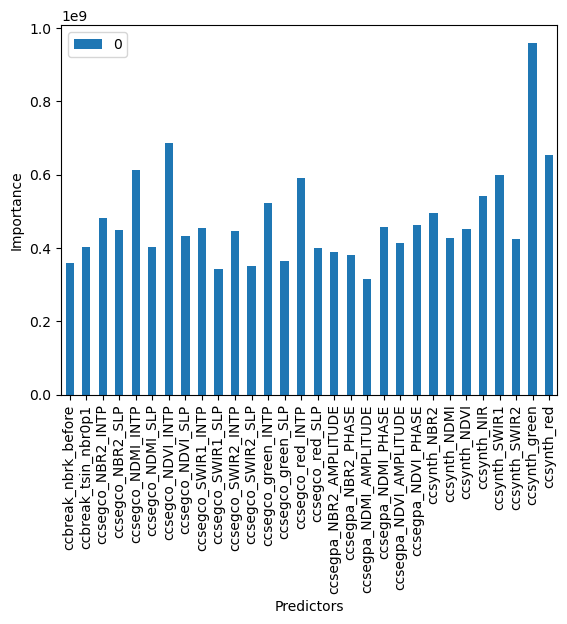

In [11]:
# Use Pandas df plotting for variable importance
RF_varimp = ee.Feature(None, ee.Dictionary(rf_train.explain()).get('importance'));
df = geemap.ee_to_df(RF_varimp).T
df.plot.bar(xlabel='Predictors', ylabel='Importance')


In [ ]:
# Not converted yet as throws an error in GEE. Error generating chart: Image.classify: The image to be classified does not contain all the bands which the classifier expects
#print(
#  ui.Chart.image.histogram({
#    image: ee.Image.cat([rf_pred_img, als_chm]),
#    region: region_geom,
#    scale: 90,
#    maxBuckets: 64,
#    minBucketWidth: 2,
#    //maxRaw: 1e5,
#    maxPixels: 1e10})
#)

In [13]:
# MAPPING
Map = geemap.Map(center=(40, -100), zoom=4)
Map.add_basemap("SATELLITE")

Map.addLayer(ccdc_syn, lsat_fcolor_viz, 'LS Synthetic, Summer 2020')
Map.addLayer(gedi_fc, {'color': 'red'}, 'GEDI Shots', 0)
#Map.addLayer(rf_pred_img, {'min':0, 'max': 50, 'palette':pal_viridis}, 'RF Predicted RH98') # fails

Map.addLayer(als_chm,{'min':0,'max':50, 'palette':pal_viridis},'ALS CHM', 0)
Map


Map(center=[40, -100], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(ch…